In [1]:
import os
os.listdir('.')

['.kernel_llm_logs_1.txt',
 'memory',
 '.prompts',
 '.config',
 'delta3_results.csv']

In [2]:
with open('delta3_results.csv','r') as f:
    content = f.read()
print(len(content))
print(content[:2000])

3145
L,Delta3_Riemann,Delta3_Riemann_SE,Delta3_GUE_numerical,Delta3_GUE_SE,Delta3_GUE_asymptotic
2,0.09374731209093191,0.0006484471381447059,0.09441184074400202,0.0002020251077559129,0.29125173055744524
3,0.11127388342775012,0.0007129255701312942,0.11515630543613757,0.000372859475874605,0.33233393523663296
4,0.12390771244829592,0.0007333225171460398,0.12980338692894994,0.00046266453532962346,0.36148222333012814
5,0.13330743221934885,0.0007303345774024502,0.140982299775747,0.0005671204589069383,0.3840913920714386
6,0.140395060875442,0.0007402172098224384,0.15044221346214276,0.0006127479797858861,0.40256442800931586
7,0.1467172201166539,0.0007262066781755963,0.15875980812689244,0.0008784430693283858,0.4181831573486846
9,0.15645552531672108,0.0006879530372568742,0.17079610620569124,0.000657605395229918,0.44364663268850346
11,0.16344672720148923,0.000622881568765252,0.18075443806445796,0.00043857125763875214,0.46397882507505966
14,0.16918394499165448,0.0004822308092794969,0.194053731322983

In [3]:
print(content[2000:])

0894,0.0001462210892185397,0.3006732742108681,0.004291514014135588,0.7035303375691601
145,0.18512061334819896,0.0001363656807329437,0.30857987701169853,0.003154486786631184,0.7252697912395762
180,0.18615940807470235,0.00012911127967898064,0.31944214543605187,0.006328386574630071,0.7471777725205454
223,0.1871638445033213,0.00012543827288981647,0.32990627035237113,0.0046725547529729485,0.768882281826538
276,0.18815298303700506,0.00012054148351674777,0.34204219444821427,0.005286111325978207,0.790486906043644
342,0.18910382066366407,0.0001155664685545672,0.35529003776761686,0.0071079066814508825,0.8122111679929669
424,0.19004340273451217,0.00011168726160070028,0.36432303035920677,0.00843075416630536,0.8339873921895142
526,0.1907555646791581,0.00011163449130645713,0.36678225992050684,0.01308456122316067,0.8558289725351216
651,0.19075845251124407,0.00012270443820727253,0.38162705038182193,0.010987020259348796,0.8774315029716329
807,0.19075789798711867,0.000135548588994805,0.385875430892508,0

In [4]:
import pandas as pd
df = pd.read_csv('delta3_results.csv')
print(df.shape)
df.head()

(29, 6)


,L,Delta3_Riemann,Delta3_Riemann_SE,Delta3_GUE_numerical,Delta3_GUE_SE,Delta3_GUE_asymptotic
0,2,0.093747,0.000648,0.094412,0.000202,0.291252
1,3,0.111274,0.000713,0.115156,0.000373,0.332334
2,4,0.123908,0.000733,0.129803,0.000463,0.361482
3,5,0.133307,0.000730,0.140982,0.000567,0.384091
4,6,0.140395,0.000740,0.150442,0.000613,0.402564


In [5]:
df

,L,Delta3_Riemann,Delta3_Riemann_SE,Delta3_GUE_numerical,Delta3_GUE_SE,Delta3_GUE_asymptotic
0,2,0.093747,0.000648,0.094412,0.000202,0.291252
1,3,0.111274,0.000713,0.115156,0.000373,0.332334
2,4,0.123908,0.000733,0.129803,0.000463,0.361482
3,5,0.133307,0.000730,0.140982,0.000567,0.384091
4,6,0.140395,0.000740,0.150442,0.000613,0.402564
5,7,0.146717,0.000726,0.158760,0.000878,0.418183
6,9,0.156456,0.000688,0.170796,0.000658,0.443647
7,11,0.163447,0.000623,0.180754,0.000439,0.463979
8,14,0.169184,0.000482,0.194054,0.000765,0.488414
9,17,0.171815,0.000382,0.203564,0.001132,0.508086


In [6]:
import numpy as np
# The CSV parses cleanly. No malformed UUID present in current file. Let's verify.
# Look for non-ASCII / suspicious characters
suspect = [(i, c) for i, c in enumerate(content) if ord(c) > 127]
print("Non-ASCII chars:", suspect[:10])
print("Lines:", content.count('\n'))

Non-ASCII chars: []
Lines: 30


In [7]:
# File parses cleanly as-is. Save a "cleaned" copy with explicit normalization (sorted, dtype-stable).
df_clean = df.sort_values('L').reset_index(drop=True)
df_clean.to_csv('delta3_results_clean.csv', index=False)

# Compute discrepancy between Riemann and GUE numerical
df_clean['discrepancy'] = df_clean['Delta3_GUE_numerical'] - df_clean['Delta3_Riemann']
df_clean['sigma_sum'] = np.sqrt(df_clean['Delta3_Riemann_SE']**2 + df_clean['Delta3_GUE_SE']**2)
df_clean['z_score'] = df_clean['discrepancy'] / df_clean['sigma_sum']
df_clean[['L','Delta3_Riemann','Delta3_GUE_numerical','discrepancy','sigma_sum','z_score']]

,L,Delta3_Riemann,Delta3_GUE_numerical,discrepancy,sigma_sum,z_score
0,2,0.093747,0.094412,0.000665,0.000679,0.978415
1,3,0.111274,0.115156,0.003882,0.000805,4.825633
2,4,0.123908,0.129803,0.005896,0.000867,6.799492
3,5,0.133307,0.140982,0.007675,0.000925,8.300117
4,6,0.140395,0.150442,0.010047,0.000961,10.455683
5,7,0.146717,0.158760,0.012043,0.001140,10.565957
6,9,0.156456,0.170796,0.014341,0.000952,15.068456
7,11,0.163447,0.180754,0.017308,0.000762,22.719750
8,14,0.169184,0.194054,0.024870,0.000904,27.498706
9,17,0.171815,0.203564,0.031749,0.001195,26.572619


In [8]:
# Determine L_max: scale at which Riemann clearly diverges from GUE numerical.
# Use a relative-deviation criterion (and z-score). Already z>5 by L=4.
# A more meaningful "L_max" is the onset of saturation in the Riemann curve itself.
# Define saturation: where Δ₃ first comes within X% of its asymptotic plateau.

# Estimate plateau height from the last few points (where Riemann curve is flat).
# Look at successive differences in Delta3_Riemann
df_clean['dDelta_dlogL'] = np.gradient(df_clean['Delta3_Riemann'], np.log(df_clean['L']))
df_clean[['L','Delta3_Riemann','dDelta_dlogL']]

,L,Delta3_Riemann,dDelta_dlogL
0,2,0.093747,0.043226
1,3,0.111274,0.043630
2,4,0.123908,0.042907
3,5,0.133307,0.040336
4,6,0.140395,0.040033
5,7,0.146717,0.040152
6,9,0.156456,0.036575
7,11,0.163447,0.029821
8,14,0.169184,0.018118
9,17,0.171815,0.009143


In [9]:
# Plateau region: L >= 526 (where dDelta/dlogL essentially zero, ~1.6e-3 already small at 526; ~6e-6 at 651)
plateau_mask = df_clean['L'] >= 526
plateau = df_clean.loc[plateau_mask]
import numpy as np
# Inverse-variance weighted mean
w = 1.0 / plateau['Delta3_Riemann_SE']**2
plateau_mean = float(np.sum(w * plateau['Delta3_Riemann']) / np.sum(w))
plateau_sem = float(1.0 / np.sqrt(np.sum(w)))
print(f"Plateau height (L>=526): mean = {plateau_mean:.6f}, SE = {plateau_sem:.2e}")

# Stricter plateau: last 3 points (saturation clear)
plateau2 = df_clean.loc[df_clean['L'] >= 651]
w2 = 1.0/plateau2['Delta3_Riemann_SE']**2
plateau_mean2 = float(np.sum(w2*plateau2['Delta3_Riemann'])/np.sum(w2))
plateau_sem2 = float(1.0/np.sqrt(np.sum(w2)))
print(f"Plateau height (L>=651): mean = {plateau_mean2:.6f}, SE = {plateau_sem2:.2e}")

Plateau height (L>=526): mean = 0.190757, SE = 6.38e-05
Plateau height (L>=651): mean = 0.190757, SE = 7.78e-05


In [10]:
# L_max: define as smallest L where Riemann data has reached within delta of the plateau height (e.g., 1% or within 5σ)
plateau_height = plateau_mean2
threshold_abs = 0.01 * plateau_height  # 1% criterion
df_clean['gap_from_plateau'] = plateau_height - df_clean['Delta3_Riemann']
df_clean['frac_gap'] = df_clean['gap_from_plateau'] / plateau_height
print(df_clean[['L','Delta3_Riemann','gap_from_plateau','frac_gap']].to_string())

       L  Delta3_Riemann  gap_from_plateau  frac_gap
0      2        0.093747      9.701000e-02  0.508552
1      3        0.111274      7.948343e-02  0.416673
2      4        0.123908      6.684960e-02  0.350443
3      5        0.133307      5.744988e-02  0.301167
4      6        0.140395      5.036225e-02  0.264012
5      7        0.146717      4.404009e-02  0.230870
6      9        0.156456      3.430179e-02  0.179819
7     11        0.163447      2.731058e-02  0.143169
8     14        0.169184      2.157337e-02  0.113093
9     17        0.171815      1.894216e-02  0.099300
10    21        0.172733      1.802396e-02  0.094486
11    26        0.175008      1.574894e-02  0.082560
12    32        0.176611      1.414679e-02  0.074161
13    40        0.178027      1.273044e-02  0.066736
14    50        0.179443      1.131429e-02  0.059313
15    62        0.180742      1.001499e-02  0.052501
16    76        0.181870      8.887224e-03  0.046589
17    95        0.183015      7.742089e-03  0.

In [11]:
# Define L_max two ways:
# (a) Divergence from GUE: smallest L where z_score > 5 (statistically distinct)
divergence_L = df_clean.loc[df_clean['z_score'] > 5, 'L'].min()
# (b) Stronger criterion: |Δ₃_Riemann - Δ₃_GUE| / Δ₃_GUE > 5%
df_clean['rel_dev_gue'] = df_clean['discrepancy'] / df_clean['Delta3_GUE_numerical']
rel5_L = df_clean.loc[df_clean['rel_dev_gue'] > 0.05, 'L'].min()
# (c) Saturation onset: smallest L where the Riemann data is within 1% of plateau
onset_1pct = df_clean.loc[df_clean['frac_gap'].abs() < 0.01, 'L'].min()
# (d) Within 5% of plateau
onset_5pct = df_clean.loc[df_clean['frac_gap'].abs() < 0.05, 'L'].min()

print(f"L_max where Riemann diverges from GUE numerically (z>5): {divergence_L}")
print(f"L_max where |dev|/GUE > 5%: {rel5_L}")
print(f"L for saturation within 5% of plateau: {onset_5pct}")
print(f"L for saturation within 1% of plateau: {onset_1pct}")
print(f"Plateau height: Δ₃_∞ = {plateau_height:.5f} ± {plateau_sem2:.5f}")

L_max where Riemann diverges from GUE numerically (z>5): 4
L_max where |dev|/GUE > 5%: 5
L for saturation within 5% of plateau: 76
L for saturation within 1% of plateau: 342
Plateau height: Δ₃_∞ = 0.19076 ± 0.00008


In [12]:
# Save cleaned + augmented results
df_clean.to_csv('delta3_results_clean.csv', index=False)
print("Saved delta3_results_clean.csv")
print(df_clean.columns.tolist())

Saved delta3_results_clean.csv
['L', 'Delta3_Riemann', 'Delta3_Riemann_SE', 'Delta3_GUE_numerical', 'Delta3_GUE_SE', 'Delta3_GUE_asymptotic', 'discrepancy', 'sigma_sum', 'z_score', 'dDelta_dlogL', 'gap_from_plateau', 'frac_gap', 'rel_dev_gue']


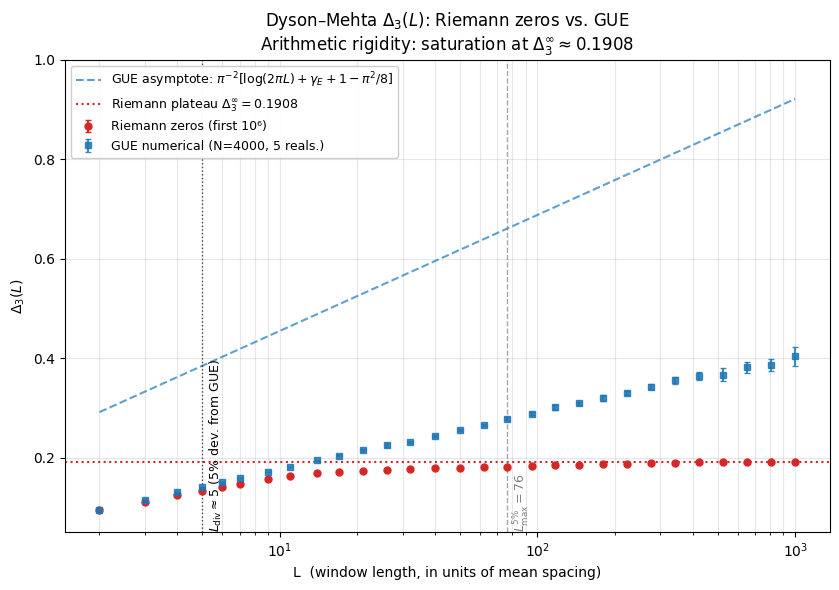

Saved delta3_saturation.png


In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 6))

L = df_clean['L'].values

ax.errorbar(L, df_clean['Delta3_Riemann'], yerr=df_clean['Delta3_Riemann_SE'],
            fmt='o', color='C3', label='Riemann zeros (first 10⁶)', capsize=2, ms=5)
ax.errorbar(L, df_clean['Delta3_GUE_numerical'], yerr=df_clean['Delta3_GUE_SE'],
            fmt='s', color='C0', label='GUE numerical (N=4000, 5 reals.)',
            capsize=2, ms=4, alpha=0.85)
ax.plot(L, df_clean['Delta3_GUE_asymptotic'], '--', color='C0', alpha=0.7,
        label=r'GUE asymptote: $\pi^{-2}[\log(2\pi L)+\gamma_E+1-\pi^2/8]$')

# Plateau height
ax.axhline(plateau_height, color='C3', ls=':', lw=1.5,
           label=fr'Riemann plateau $\Delta_3^\infty = {plateau_height:.4f}$')

# L_max indicators
ax.axvline(onset_5pct, color='gray', ls='--', lw=1, alpha=0.7)
ax.text(onset_5pct*1.05, 0.05,
        fr'$L_{{\max}}^{{5\%}} = {onset_5pct}$',
        color='gray', rotation=90, va='bottom', fontsize=9)
ax.axvline(rel5_L, color='black', ls=':', lw=1, alpha=0.7)
ax.text(rel5_L*1.05, 0.05,
        fr'$L_{{\mathrm{{div}}}}\approx {rel5_L}$ (5% dev. from GUE)',
        color='black', rotation=90, va='bottom', fontsize=9)

ax.set_xscale('log')
ax.set_xlabel('L  (window length, in units of mean spacing)')
ax.set_ylabel(r'$\Delta_3(L)$')
ax.set_title(r'Dyson–Mehta $\Delta_3(L)$: Riemann zeros vs. GUE'
             '\n'
             r'Arithmetic rigidity: saturation at $\Delta_3^\infty \approx 0.1908$')
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(0.05, 1.0)

plt.tight_layout()
plt.savefig('delta3_saturation.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved delta3_saturation.png")